# What is Gradient Descent Algorithm ?

> Gradient Descent is an optimization algorithm used to minimize a cost function by updating parameters in the opposite direction of the gradient (slope).
> $$
\theta = \theta - \alpha \cdot \frac{\partial J(\theta)}{\partial \theta}
$$
> In above,

> $J(\theta)$ is the cost function,

> $\alpha$ is the learning rate,

> while $\theta$ is the parameter we are updating.

X shape: (100, 1)
y shape:(100, 1)
X_b shape: (100, 2)

Learned parameters: [[3.79677863]
 [3.22819193]]


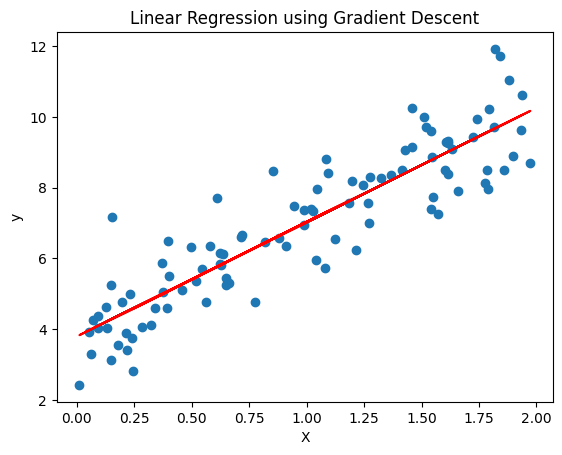

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Generate dummy data
X = 2 * np.random.rand(100, 1)                               # train data
y = 4 + 3 * X + np.random.randn(100, 1)                      # test data
print("X shape: {}\ny shape:{}".format(X.shape,y.shape))

# Add bias term to X
X_b = np.c_[np.ones((100, 1)), X]                            # train data with bias
print("X_b shape: {}\n".format(X_b.shape))

# Initialize theta - why?
### because, we will start with some random value for theta, 
### calculate how far off our predictions are, and then adjust theta using gradients.
### shape is (2, 1) because we have 2 features, including the bias.
###
theta = np.random.randn(2, 1)   # can be understood as model parameters - similar to 
                                # weights, bias

# Gradient Descent
learning_rate = 0.1
n_iterations = 1000
m = len(X_b)                    # total number of examples

# cost function is taken as MSE
# and gradient denotes derivative of the cost function with respect to the parameters 
for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - learning_rate * gradients
print("Learned parameters: {}".format(theta))

# Plot
plt.scatter(X, y)
plt.plot(X, 
         X_b.dot(theta),                           # y = m.x + c
         color='red')                
plt.title("Linear Regression using Gradient Descent")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# Logistic Regression using Gradient Descent

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generate dummy classification data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = (X > 1).astype(int)  # Binary labels: 0 if x <= 1, else 1

# Add bias term
X_b = np.c_[np.ones((100, 1)), X]
print("X_b shape: {}\n".format(X_b.shape))


X_b shape: (100, 2)



Learned parameters: [[-4.17315844]
 [ 4.40960542]]


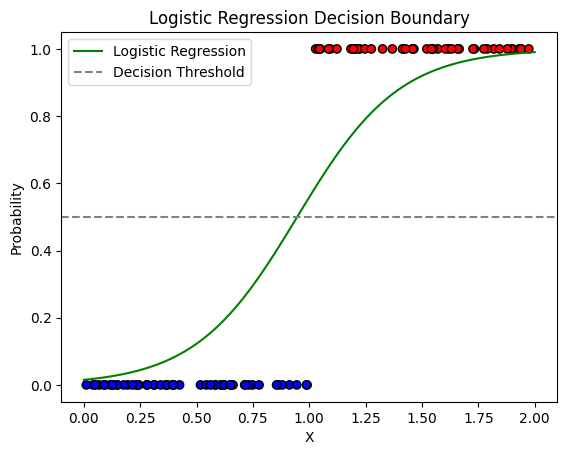

In [31]:
# Initialize theta
theta = np.random.randn(2, 1)

# Gradient Descent for Logistic Regression
learning_rate = 0.1
n_iterations = 1000
m = len(X_b)

for iteration in range(n_iterations):
    z = X_b.dot(theta)
    y_pred = sigmoid(z)
    gradients = 1/m * X_b.T.dot(y_pred - y)
    theta -= learning_rate * gradients

print("Learned parameters: {}".format(theta))

# Plot decision boundary
plt.scatter(X, y, c=y, cmap='bwr', edgecolors='k')
x_vals = np.linspace(0, 2, 100).reshape(-1, 1)
x_vals_b = np.c_[np.ones((100, 1)), x_vals]
probs = sigmoid(x_vals_b.dot(theta))
plt.plot(x_vals, probs, color='green', label='Logistic Regression')
plt.axhline(0.5, color='gray', linestyle='--', label='Decision Threshold')
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("X")
plt.ylabel("Probability")
plt.legend()
plt.show()

# How does a Decision tree work for Classification?

let's use a tiny dataset,
| Feature (X1) | Feature (X2) | Class |
| ------------ | ------------ | ----- |
| 1            | 1            | 0     |
| 2            | 1            | 0     |
| 3            | 2            | 1     |
| 4            | 3            | 1     |


In [32]:
import numpy as np
from collections import Counter

# Simple dataset
X = np.array([
    [1, 1],
    [2, 1],
    [3, 2],
    [4, 3]
])
y = np.array([0, 0, 1, 1])

> Gini Index, Gini = 0 (pure); 1 (impure)
$$
\text{Gini}(y) = 1 - \sum_{i=1}^{k} p_i^2
$$

In [33]:
# Gini Impurity
### measures how "mixed" the classes are in a node --> Lower impurity = purer node
def gini(y):
    '''
    y = list()
    return
        impurity = float
    '''
    counts = Counter(y)   # Count how many of each class label
    impurity = 1 
    for label in counts:
        prob = counts[label] / len(y)  # p_i = proportion of class 'label'
        impurity -= prob ** 2          # Subtract p_i² from 1
    return impurity

In [34]:
# Split the dataset
def split(X, y, feature_idx, threshold):
    '''
    get X,y to split and also feature to use for splitting along with threshold to
    apply on the feature to split.
    '''
    left_idx = X[:, feature_idx] <= threshold
    right_idx = X[:, feature_idx] > threshold
    
    return X[left_idx], y[left_idx], X[right_idx], y[right_idx]

In [35]:
# Find the best split
def best_split(X, y):
    """
    Finds the best feature and threshold to split the dataset in order to 
    minimize Gini impurity.

    The function evaluates all unique values in each feature column as potential thresholds.
    For each candidate split, it computes the weighted Gini impurity of the 
    left and right subsets. The split that minimizes the Gini impurity is 
    selected as the best.
    """

    best_gini = 1               # worst case --> completely impure node
    best_feature = None         # initialization
    best_threshold = None       # initialization

    for feature_idx in range(X.shape[1]):   # iterate over each feature in train set
        thresholds = np.unique(X[:, feature_idx])  # these are unique value in the feature
                                                   # which are possible threshold values
        # we will try splitting at each threshold value
        for threshold in thresholds:
            X_left, y_left, X_right, y_right = split(X, y, feature_idx, threshold)
            if len(y_left) == 0 or len(y_right) == 0:
                continue                         # if we get empty group on splitting
                                                 # we will move to next threshold
            # weighted GINI INDEX calculation
            weight_left = len(y_left) / len(y)
            gini_split = weight_left * gini(y_left) + (1 - weight_left) * gini(y_right)
            if gini_split < best_gini:     # at 1st iteration, best gini = 1
                best_gini = gini_split
                best_feature = feature_idx
                best_threshold = threshold

    return best_feature, best_threshold

In [36]:
# Build tree recursively (dict format)
def build_tree(X, y, depth=0):
    '''
    It returns
        For a leaf node: {'label': class}
        and, an internal node: {'feature': i, 'threshold': t, 'left': ..., 'right': ...}
    '''
    # Stopping condition: all labels are same [LEAF NODE]
    if len(set(y)) == 1:
        return {'label': y[0]}

    # Stopping condition: no features left [LEAF NODE]
    if X.shape[1] == 0:
        return {'label': Counter(y).most_common(1)[0][0]}

    # Find best split
    feature_idx, threshold = best_split(X, y)
    if feature_idx is None:    # [LEAF NODE]
        return {'label': Counter(y).most_common(1)[0][0]}

    X_left, y_left, X_right, y_right = split(X, y, feature_idx, threshold)
    return {
        'feature': feature_idx,
        'threshold': threshold,
        'left': build_tree(X_left, y_left, depth+1),
        'right': build_tree(X_right, y_right, depth+1)
    }

In [37]:
def print_tree_pretty(tree, prefix="", is_left=True):
    """
    Pretty-prints the decision tree using Unicode tree structure.
    
    Parameters:
    -----------
    tree : dict
        The decision tree represented as nested dictionaries.
    prefix : str
        Prefix string used for indentation and tree structure.
    is_left : bool
        True if the current node is a left child; affects tree branches.
    """
    if 'label' in tree:
        print(prefix + ("├── " if is_left else "└── ") + f"Predict: {tree['label']}")
    else:
        print(prefix + ("├── " if is_left else "└── ") + f"[X[{tree['feature']}] <= {tree['threshold']}]")
        
        # Extend prefix for child nodes
        child_prefix = prefix + ("│   " if is_left else "    ")
        
        # Left branch
        print_tree_pretty(tree['left'], child_prefix, is_left=True)
        
        # Right branch
        print_tree_pretty(tree['right'], child_prefix, is_left=False)


In [38]:
# Build and print the tree
tree = build_tree(X, y)
print_tree_pretty(tree)

├── [X[0] <= 2]
│   ├── Predict: 0
│   └── Predict: 1


## Printing from a bigger dataset, just to understand

In [39]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

# For simplicity: Only two classes and two features
# Let's classify Setosa (0) vs Versicolor (1) using petal length and petal width
X = iris.data[:, 2:]  # keep petal length and width
y = iris.target       # use all 3 classes
print("X shape: {}, y shape: {}".format(X.shape, y.shape))
print("Unique labels: {}\n".format(np.unique(y)))

# === Build and Print Tree ===
tree = build_tree(X, y)
print_tree_pretty(tree)

X shape: (150, 2), y shape: (150,)
Unique labels: [0 1 2]

├── [X[0] <= 1.9]
│   ├── Predict: 0
│   └── [X[1] <= 1.7]
│       ├── [X[0] <= 4.9]
│       │   ├── [X[1] <= 1.6]
│       │   │   ├── Predict: 1
│       │   │   └── Predict: 2
│       │   └── [X[1] <= 1.5]
│       │       ├── Predict: 2
│       │       └── [X[0] <= 5.1]
│       │           ├── Predict: 1
│       │           └── Predict: 2
│       └── [X[0] <= 4.8]
│           ├── Predict: 2
│           └── Predict: 2


# How does a Decision tree work for Regression ?

> - Start with all data.
> - For each feature and every possible split point:
>   - Compute MSE (Mean Squared Error) for the two resulting groups.
> - Choose the split with lowest MSE.
> - Repeat recursively for child nodes.
> - **Stop when**:
>   - **Minimum number of samples per leaf reached**
>   - **Maximum depth is reached**
>   - **MSE improvement is too small**

In [40]:
import numpy as np
from collections import namedtuple

# Define a node class
class TreeNode:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index  # which feature to split
        self.threshold = threshold          # split value
        self.left = left                    # left child (TreeNode)
        self.right = right                  # right child
        self.value = value                  # if leaf, predicted value

# Mean Squared Error
def mse(y):
    return np.mean((y - np.mean(y)) ** 2)

# Split dataset
def split_dataset(X, y, feature_index, threshold):
    left_mask = X[:, feature_index] <= threshold
    right_mask = ~left_mask
    return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

# Find best split
def best_split(X, y):
    best_mse = float('inf')
    best_feat, best_thresh = None, None
    
    for feature_index in range(X.shape[1]):
        thresholds = np.unique(X[:, feature_index])
        for thresh in thresholds:
            X_left, y_left, X_right, y_right = split_dataset(X, y, feature_index, thresh)
            if len(y_left) == 0 or len(y_right) == 0:
                continue
            mse_split = (len(y_left) * mse(y_left) + len(y_right) * mse(y_right)) / len(y)
            if mse_split < best_mse:
                best_mse = mse_split
                best_feat = feature_index
                best_thresh = thresh
    return best_feat, best_thresh

# Build tree recursively
def build_tree(X, y, max_depth=3, min_samples=5, depth=0):
    if depth >= max_depth or len(y) <= min_samples or np.all(y == y[0]):
        return TreeNode(value=np.mean(y))

    feature_index, threshold = best_split(X, y)
    if feature_index is None:
        return TreeNode(value=np.mean(y))

    X_left, y_left, X_right, y_right = split_dataset(X, y, feature_index, threshold)
    left_child = build_tree(X_left, y_left, max_depth, min_samples, depth + 1)
    right_child = build_tree(X_right, y_right, max_depth, min_samples, depth + 1)
    
    return TreeNode(feature_index, threshold, left_child, right_child)

# Predict for one sample
def predict_sample(node, x):
    if node.value is not None:
        return node.value
    if x[node.feature_index] <= node.threshold:
        return predict_sample(node.left, x)
    else:
        return predict_sample(node.right, x)

# Predict for all samples
def predict(tree, X):
    return np.array([predict_sample(tree, x) for x in X])


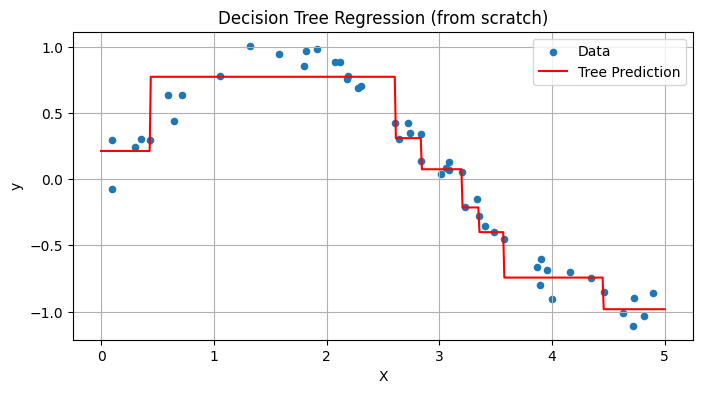

In [41]:
import matplotlib.pyplot as plt

# Toy regression data
np.random.seed(0)
X = np.sort(np.random.rand(50, 1) * 5, axis=0)
y = np.sin(X).ravel() + 0.1 * np.random.randn(50)

# Fit tree
tree = build_tree(X, y, max_depth=3)

# Predict
X_test = np.linspace(0, 5, 500).reshape(-1, 1)
y_pred = predict(tree, X_test)

# Plot
plt.figure(figsize=(8, 4))
plt.scatter(X, y, label='Data', s=20)
plt.plot(X_test, y_pred, label='Tree Prediction', color='red')
plt.title("Decision Tree Regression (from scratch)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


In [42]:
def print_tree(node, feature_names=None, depth=0, prefix=""):
    indent = "    " * depth
    if node.value is not None:
        print(f"{indent}{prefix}Predict: {node.value:.3f}")
    else:
        feature_name = f"X[{node.feature_index}]" if feature_names is None else feature_names[node.feature_index]
        print(f"{indent}{prefix}[{feature_name} <= {node.threshold:.3f}]")
        print_tree(node.left, feature_names, depth + 1, "├── ")
        print_tree(node.right, feature_names, depth + 1, "└── ")

print_tree(tree)

[X[0] <= 3.200]
    ├── [X[0] <= 2.609]
        ├── [X[0] <= 0.436]
            ├── Predict: 0.213
            └── Predict: 0.773
        └── [X[0] <= 2.842]
            ├── Predict: 0.310
            └── Predict: 0.075
    └── [X[0] <= 3.576]
        ├── [X[0] <= 3.353]
            ├── Predict: -0.214
            └── Predict: -0.400
        └── [X[0] <= 4.459]
            ├── Predict: -0.744
            └── Predict: -0.982


## Let's see bias-variance trade-off for `max_depth`

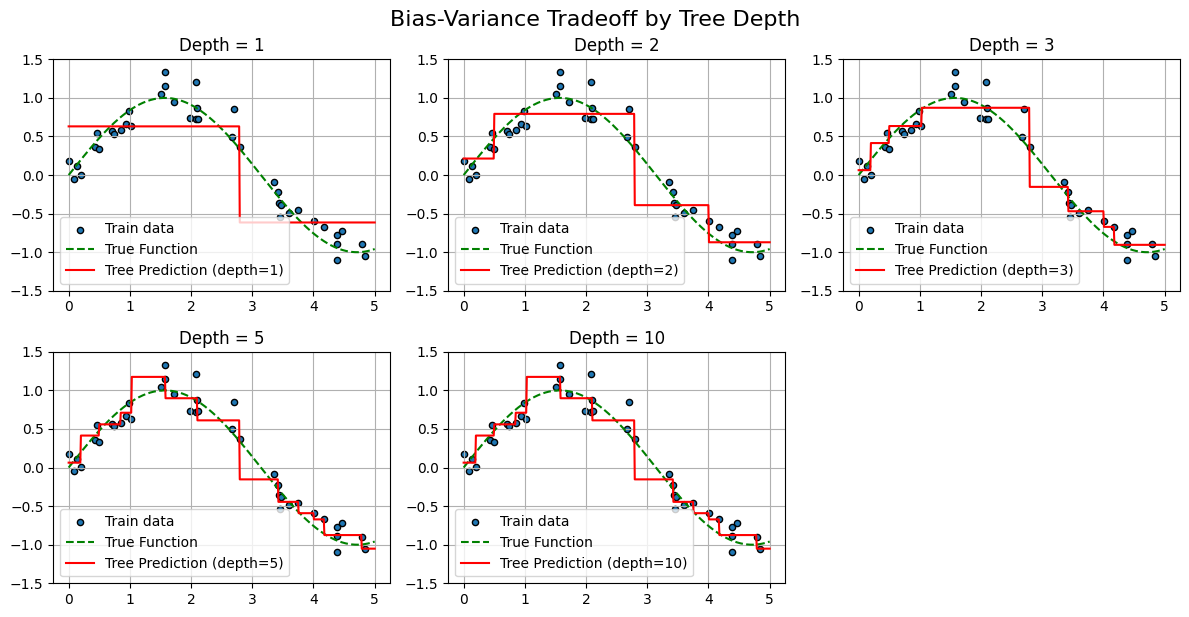

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Use your earlier tree code: TreeNode, build_tree(), predict(), etc.

# Generate data
np.random.seed(1)
X_train = np.sort(np.random.rand(40, 1) * 5, axis=0)
y_train = np.sin(X_train).ravel() + 0.2 * np.random.randn(40)

X_test = np.linspace(0, 5, 500).reshape(-1, 1)
y_true = np.sin(X_test).ravel()

# Try different depths
depths = [1, 2, 3, 5, 10]

plt.figure(figsize=(12, 6))
for i, depth in enumerate(depths, 1):
    tree = build_tree(X_train, y_train, max_depth=depth)
    y_pred = predict(tree, X_test)

    plt.subplot(2, 3, i)
    plt.scatter(X_train, y_train, s=20, edgecolor='k', label='Train data')
    plt.plot(X_test, y_true, 'g--', label='True Function')
    plt.plot(X_test, y_pred, 'r', label=f'Tree Prediction (depth={depth})')
    plt.title(f"Depth = {depth}")
    plt.ylim(-1.5, 1.5)
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Bias-Variance Tradeoff by Tree Depth", fontsize=16, y=1.02)
plt.show()

# When to use Gini Index v/s Entropy for splitting Decision tree node ?

> - **Gini Index** measures the probability of a randomly chosen sample being incorrectly classified if it's randomly labeled according to the distribution of labels in the node. This means,
>   - At a given node in a decision tree, there might be samples from multiple classes.
>   - If you pick a sample at random and assign it a class label randomly, based on the class proportions, Gini tells you the chance you'll get it wrong.
> - On the other hand, **Entropy** measures the level of uncertainty or disorder in the class distribution.

> - **Entropy is best when we have skewed distribution or there is imbalance in the dataset.** 

In [44]:
import numpy as np
from collections import Counter
import math

# Gini Index
def gini(y):
    counts = Counter(y)
    total = len(y)
    impurity = 1
    for c in counts:
        p = counts[c] / total
        impurity -= p ** 2
    return impurity

# Entropy
def entropy(y):
    counts = Counter(y)
    total = len(y)
    ent = 0
    for c in counts:
        p = counts[c] / total
        ent -= p * math.log2(p)
    return ent

# Datasets
y_balanced = ['A'] * 5 + ['B'] * 5
y_skewed   = ['A'] * 9 + ['B'] * 1
y_very_skewed = ['A'] * 99 + ['B'] * 1

# Print values
print("Balanced (5A, 5B):")
print("  Gini:", gini(y_balanced))
print("  Entropy:", entropy(y_balanced))

print("\nSkewed (9A, 1B):")
print("  Gini:", gini(y_skewed))
print("  Entropy:", entropy(y_skewed))

print("\nVery Skewed (99A, 1B):")
print("  Gini:", gini(y_very_skewed))
print("  Entropy:", entropy(y_very_skewed))


Balanced (5A, 5B):
  Gini: 0.5
  Entropy: 1.0

Skewed (9A, 1B):
  Gini: 0.17999999999999994
  Entropy: 0.4689955935892812

Very Skewed (99A, 1B):
  Gini: 0.01980000000000003
  Entropy: 0.08079313589591118


> - Gini and Entropy both go down as the node becomes purer.
> - Entropy decreases slower, highlighting subtle differences in class distributions, making it more sensitive to imbalance.

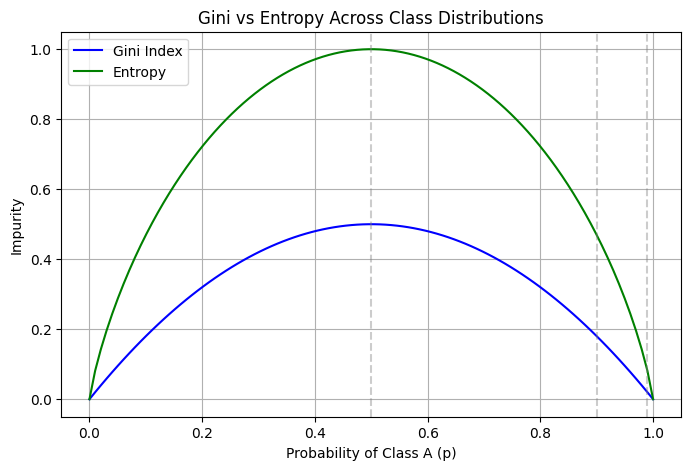

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Probability of class A (from 0 to 1)
p_vals = np.linspace(0, 1, 100)
gini_vals = []
entropy_vals = []

# Calculate Gini and Entropy for each class distribution
for p in p_vals:
    # Avoid log(0)
    if p == 0 or p == 1:
        ent = 0
    else:
        ent = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
    gini = 1 - p**2 - (1 - p)**2

    entropy_vals.append(ent)
    gini_vals.append(gini)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(p_vals, gini_vals, label='Gini Index', color='blue')
plt.plot(p_vals, entropy_vals, label='Entropy', color='green')
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.4)
plt.axvline(0.9, color='gray', linestyle='--', alpha=0.4)
plt.axvline(0.99, color='gray', linestyle='--', alpha=0.4)
plt.xlabel("Probability of Class A (p)")
plt.ylabel("Impurity")
plt.title("Gini vs Entropy Across Class Distributions")
plt.legend()
plt.grid(True)
plt.show()

# What is difference between Ridge and Lasso Regularization?

| Regularization | Penalty Term       | What it does                                  |   |                                                                                    |
| -------------- | ------------------ | --------------------------------------------- | - | ---------------------------------------------------------------------------------- |
| **Ridge (L2)** | $\lambda \sum w^2$ | Shrinks all weights, **does not make them 0** |   |                                                                                    |
| **Lasso (L1)** | $\lambda \sum{|w|}$  | Can **shrink some weights to exactly 0**, so it's useful for **feature selection** |


> - The spherical constraint (imposed by Ridge) promotes equal shrinking of all coefficients.
> - The optimal point on the ellipse that touches the sphere will usually lie on the surface, but not at the origin or on an axis, unless the ellipse is perfectly aligned in such a way that its minimum lands there.


**How coefficients can shrink to zero for Lasso?**
- When we're doing linear regression, we're trying to minimize the cost function (like MSE).
- The contours of this cost function are ellipses (think: stretched circles) <u>centered around the point where the unregularized solution lies</u>.
- Lasso adds an L1 constraint, which forms a diamond-shaped region (in 2D). This diamond limits where your solution can lie.
- The cost function wants to pick the best coefficients to minimize error—but now it’s constrained to only pick values inside or on the surface of the diamond.
- Because of the sharp corners on the axes of this diamond, the lowest cost often happens right at a corner.




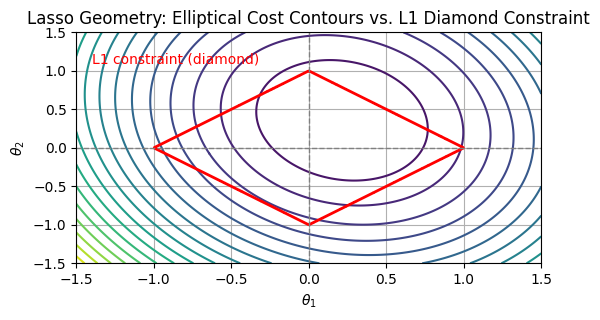

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Create a mesh grid
theta1 = np.linspace(-1.5, 1.5, 400)
theta2 = np.linspace(-1.5, 1.5, 400)
T1, T2 = np.meshgrid(theta1, theta2)

# Simulated cost function: quadratic form (elliptical contours)
Z = (3*T1 + T2 - 1)**2 + (T1 - 2*T2 + 0.5)**2

# L1 constraint region (diamond)
lasso_constraint = np.abs(T1) + np.abs(T2)

# Plot
plt.figure(figsize=(6, 3))
contours = plt.contour(T1, T2, Z, levels=20, cmap='viridis')
plt.contour(T1, T2, lasso_constraint, levels=[1], colors='red', linewidths=2)

# Visual annotations
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.text(-1.4, 1.1, 'L1 constraint (diamond)', color='red', fontsize=10)
plt.title('Lasso Geometry: Elliptical Cost Contours vs. L1 Diamond Constraint', fontsize=12)
plt.xlabel(r'$\theta_1$')
plt.ylabel(r'$\theta_2$')
#plt.gca().set_aspect('equal')
plt.grid(True)
plt.show()

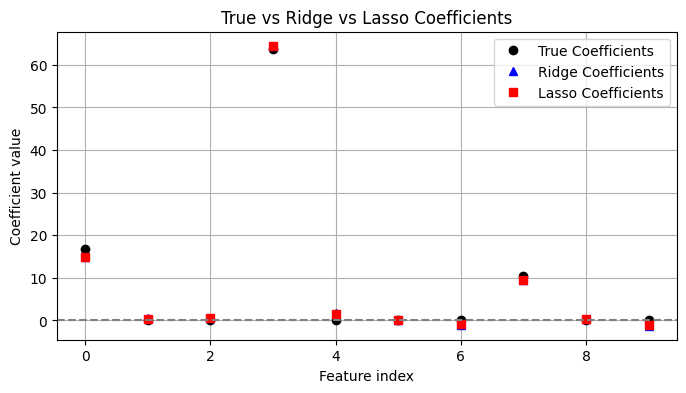

In [47]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

# === Generate Synthetic Data for Regression ===
np.random.seed(42)
X, y, coef_true = make_regression(
    n_samples=100,
    n_features=10,
    n_informative=3,      # only 3 features actually matter
    noise=10,             # adds Gaussian noise to the target, simulating real-world imperfections
    coef=True             # returns the true coefficients used to generate y
)

# Scale data to normalize regularization effect
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === Apply Lasso and Ridge ===
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=0.1)

lasso.fit(X_scaled, y)
ridge.fit(X_scaled, y)

# === Compare Coefficients ===
plt.figure(figsize=(8, 4))
plt.plot(coef_true, 'ko', label='True Coefficients')
plt.plot(ridge.coef_, 'b^', label='Ridge Coefficients')
plt.plot(lasso.coef_, 'rs', label='Lasso Coefficients')
plt.axhline(0, color='gray', linestyle='--')
plt.title('True vs Ridge vs Lasso Coefficients')
plt.xlabel('Feature index')
plt.ylabel('Coefficient value')
plt.legend()
plt.grid(True)
plt.show()

# Why can’t we use MSE as a cost function in Logistic Regression?

Logistic regression is used for binary classification — predicting 0 or 1 and uses the sigmoid function to convert linear output into a probability between 0 and 1.

MSE is given by, MSE=1mm∑i=1(ˆyi−yi)2\text{MSE} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2

This works well when:
- The model output is linear (and we are interested in deviations from this linear output)
- Errors are normally distributed (the deviations)

But, logistic regression outputs non-linear probabilities (because of the sigmoid applied to the linear output). Also, target is binary (0 or 1).

> - Non-convex loss: Logistic regression uses sigmoid output (0–1), and using MSE leads to a non-convex cost surface, making optimization unstable.
> - Poor gradient behavior: Gradients can become very small → slow learning
> - Inappropriate error assumption: MSE assumes Gaussian distribution of errors (suitable for regression), but logistic regression assumes Bernoulli.
>   - Because in binary classification, the output is either 0 or 1. This matches exactly with a Bernoulli distribution, which models: The probability of a single event with two possible outcomes (like flipping a coin: heads or tails).

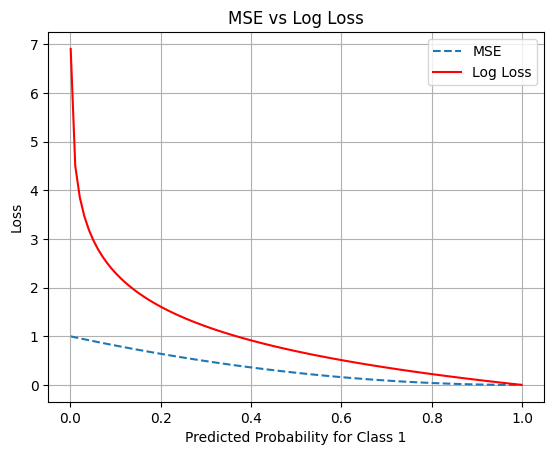

In [48]:
### Notice how Log Loss penalizes incorrect high-confidence predictions more harshly

x = np.linspace(0.001, 0.999, 100)   # x axis
mse = (1 - x)**2
log_loss = -np.log(x)

plt.plot(x, mse, label='MSE', linestyle='--')
plt.plot(x, log_loss, label='Log Loss', color='red')
plt.xlabel('Predicted Probability for Class 1')
plt.ylabel('Loss')
plt.title('MSE vs Log Loss')
plt.legend()
plt.grid(True)
plt.show()

**key takeaways**
> - both losses reach minimum when prediction = true label
> - log-loss penalizes confident wrong prediction much more. This means log-loss punishes wrong, confident predictions hard.
> - MSE is too gentle for classification problems.

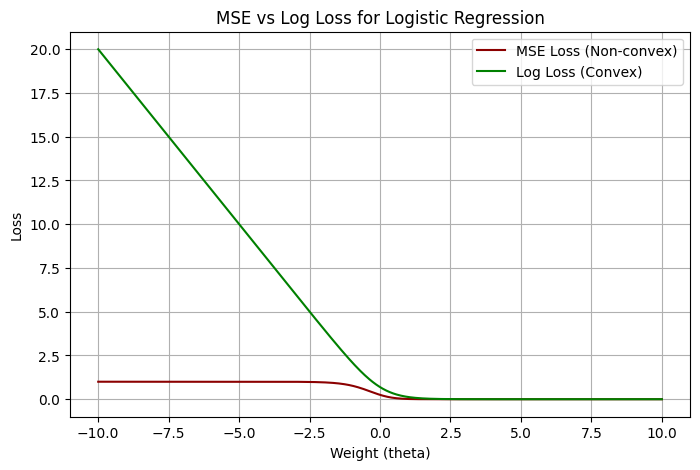

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# One data point
x = 2
y_true = 1

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# MSE loss after sigmoid
def mse_loss(theta):
    z = theta * x
    y_pred = sigmoid(z)
    return (y_pred - y_true) ** 2

# Theta values (weights)
theta_vals = np.linspace(-10, 10, 500)
loss_vals = [mse_loss(theta) for theta in theta_vals]

# Binary cross-entropy (log loss)
def log_loss(theta):
    z = theta * x
    y_pred = sigmoid(z)
    return - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Add to plot
log_loss_vals = [log_loss(theta) for theta in theta_vals]

plt.figure(figsize=(8, 5))
plt.plot(theta_vals, loss_vals, label='MSE Loss (Non-convex)', color='darkred')
plt.plot(theta_vals, log_loss_vals, label='Log Loss (Convex)', color='green')
plt.title("MSE vs Log Loss for Logistic Regression")
plt.xlabel("Weight (theta)")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


**key takeaways**
> - logg-loss curve is convex. It has a nice U-shape with only ONE GLOBAL MINIMUM.
>   -  This is great for gradient descent as the optimizer can easily find the minima.
> - MSE is fairly flat and has plateau for negative $\theta$ 

## Increasing data points for better 3D visualization

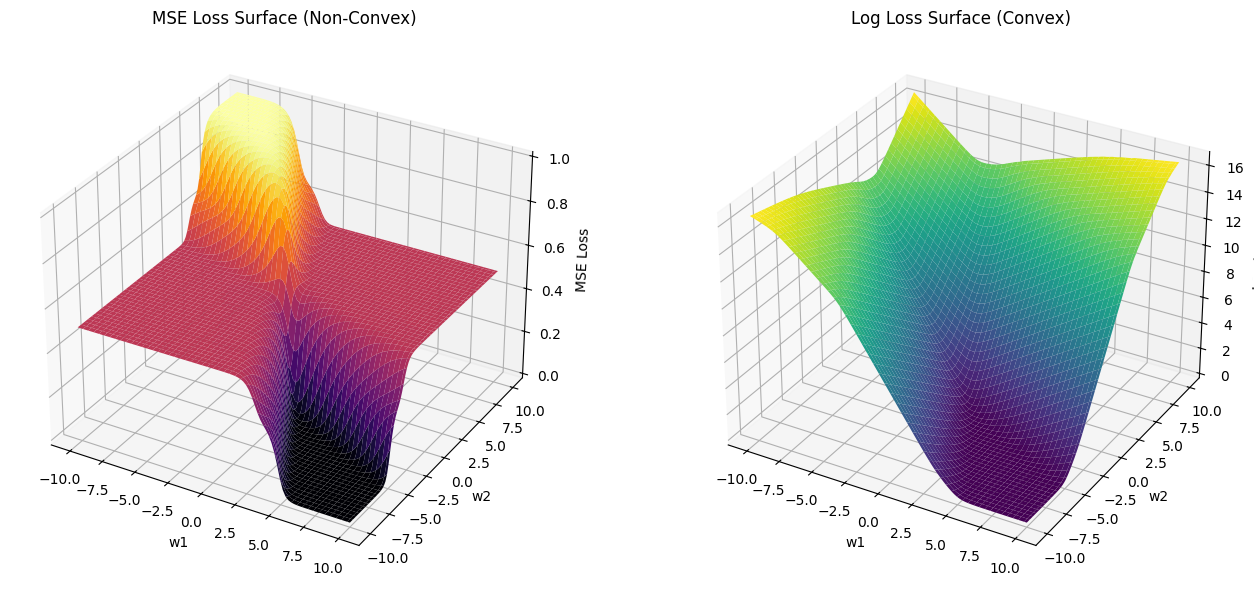

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create simple dataset
X = np.array([
    [1, 2],
    [1, 3],
    [2, 1],
    [3, 1],
    [4, 2],
    [2, 4]
])
y = np.array([0, 0, 1, 1, 1, 0])

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Loss functions with two weights w1, w2
def mse_loss(w1, w2):
    z = X[:, 0] * w1 + X[:, 1] * w2
    y_pred = sigmoid(z)
    return np.mean((y_pred - y) ** 2)

def log_loss(w1, w2):
    z = X[:, 0] * w1 + X[:, 1] * w2
    y_pred = sigmoid(z)
    eps = 1e-15
    return -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))

# Create weight grid
W1, W2 = np.meshgrid(np.linspace(-10, 10, 100), np.linspace(-10, 10, 100))
MSE = np.zeros_like(W1)
LOG = np.zeros_like(W2)

# Compute losses over the grid
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        MSE[i, j] = mse_loss(W1[i, j], W2[i, j])
        LOG[i, j] = log_loss(W1[i, j], W2[i, j])

# Plot MSE surface
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(W1, W2, MSE, cmap='inferno')
ax1.set_title('MSE Loss Surface (Non-Convex)')
ax1.set_xlabel('w1')
ax1.set_ylabel('w2')
ax1.set_zlabel('MSE Loss')

# Plot Log Loss surface
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(W1, W2, LOG, cmap='viridis')
ax2.set_title('Log Loss Surface (Convex)')
ax2.set_xlabel('w1')
ax2.set_ylabel('w2')
ax2.set_zlabel('Log Loss')

plt.tight_layout()
plt.show()

In [51]:
import numpy as np
import plotly.graph_objects as go

# Interactive MSE Plot
fig1 = go.Figure(data=[go.Surface(z=MSE, x=W1, y=W2, colorscale='Reds')])
fig1.update_layout(
    title='MSE Loss Surface (Non-Convex)',
    scene=dict(
        xaxis_title='w1',
        yaxis_title='w2',
        zaxis_title='Loss',
    ),
    margin=dict(l=0, r=0, b=0, t=30)
)

# Interactive Log Loss Plot
fig2 = go.Figure(data=[go.Surface(z=LOG, x=W1, y=W2, colorscale='Viridis')])
fig2.update_layout(
    title='Log Loss Surface (Convex)',
    scene=dict(
        xaxis_title='w1',
        yaxis_title='w2',
        zaxis_title='Loss',
    ),
    margin=dict(l=0, r=0, b=0, t=30)
)

# Show interactive plots
fig1.show()
fig2.show()

# How does K-means work?

> 1. Choose the number of clusters (K)
> 2. Initialize K centroids randomly (could be actual data points or random locations)
> 3. Assign each point to the nearest centroid (using Euclidean distance)
> 4. Update each centroid as the mean of all points assigned to it
> 5. Repeat steps 3 and 4 until, <u>Centroids no longer change significantly</u> (OR) <u>maximum iterations reached</u>

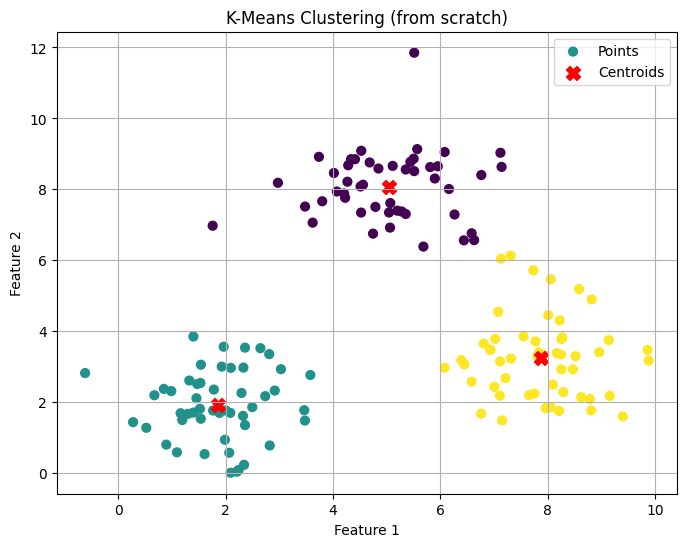

In [52]:
# -------------------------------
# Create synthetic data manually
# -------------------------------
np.random.seed(42)
cluster_centers = [(2, 2), (8, 3), (5, 8)]    # 3 cluster centers
X = []
for cx, cy in cluster_centers:
    points = np.random.randn(50, 2) + np.array([cx, cy])
    X.append(points)
X = np.vstack(X)  # Final dataset of shape (150, 2)

# -------------------------------
# Define K-Means from scratch
# -------------------------------
def initialize_centroids(X, k):
    indices = np.random.choice(len(X), k, replace=False)   # randomly select k indices
    return X[indices]

def assign_clusters(X, centroids):
    # X[:, np.newaxis] --> adds axis needed for broadcasting with centroids
    ### changes (150, 2) --> (150, 1, 2)
    # centroid shape --> (k, 2)
    # subtracting gives shape of (150, k, 2) --> for 150 samples, tells how far each is from
    #                                            k centroids
    # distance has shape of (150, k) --> gives distance of a point from all k centroids
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    return np.array(
        [X[labels == i].mean(axis=0) for i in range(k)]
    )

def kmeans(X, k, n_iters=100):
    centroids = initialize_centroids(X, k)
    for _ in range(n_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids

# -------------------------------
# Run and plot
# -------------------------------
k = 3
labels, centroids = kmeans(X, k)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40, label='Points')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=100, marker='X', label='Centroids')
plt.title("K-Means Clustering (from scratch)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

# What is elbow method in K-means?

1. K-means is run for different values of k.
2. For each, WCSS (Within Cluster Sum of Squares) is calculated and plotted.
3. WCSS should be small. Thus, optimum k is where WCSS is low and doesn't reduce much even if k increases.
> WCSS is also called as **inertia** in scikit-learn.

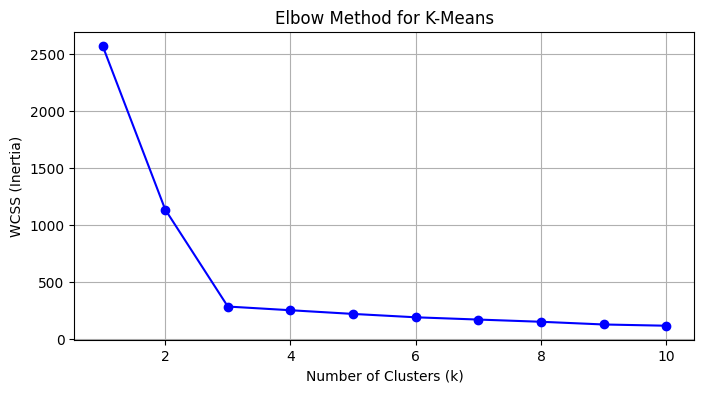

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Create custom 2D data
np.random.seed(42)
cluster_1 = np.random.randn(50, 2) + np.array([1, 1])    # Cluster 1: Around (1,1)
cluster_2 = np.random.randn(50, 2) + np.array([5, 5])    # Cluster 2: Around (5,5)
cluster_3 = np.random.randn(50, 2) + np.array([9, 1])    # Cluster 3: Around (9,1)

# Stack them together into one dataset
X = np.vstack((cluster_1, cluster_2, cluster_3))

# WCSS calculation
def calculate_wcss(X, labels, centroids):
    '''
    calculate wcss for a given configuration of K-Means i.e., given "K"
    '''
    wcss = 0
    for i in range(len(centroids)):
        points_in_cluster = X[labels == i]
        distances = np.linalg.norm(points_in_cluster - centroids[i], axis=1)
        wcss += np.sum(distances ** 2)
    return wcss
    
# K-means and Elbow Method
wcss_store = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    labels = kmeans.labels_              # Cluster assignments --> [0,1,1,3,4,.....]
    centroids = kmeans.cluster_centers_  # Centroid loc --> [[2,1], [3,2] ...] ... k centroids
    wcss = calculate_wcss(X, labels, centroids)
    wcss_store.append(wcss)

# Plot WCSS vs. k
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss_store, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for K-Means')
plt.grid(True)
plt.show()

# What is exponential smoothing ?

> It is a technique that assigns exponentially decreasing weights to past observations, giving more importance to recent values in forecasting future values.
> $$
\hat{y}_t = \alpha*y_{t-1} + (1 - \alpha)*\hat{y}_{t-1}
$$

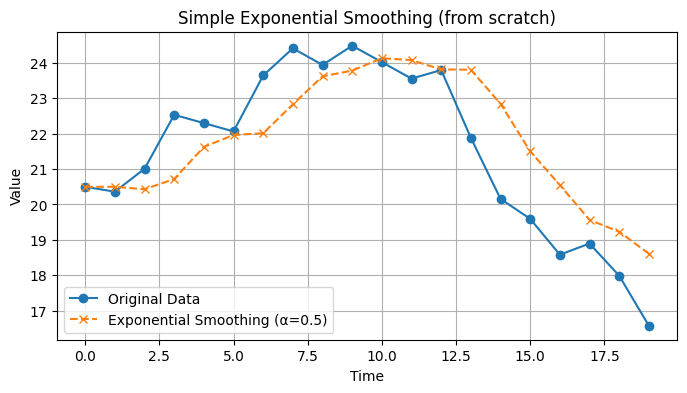

In [54]:
import pandas as pd
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Dummy time series data
np.random.seed(42)
data = pd.Series(20 + np.random.randn(20).cumsum())

# Smoothing function
def exponential_smoothing(series, alpha):
    result = [series[0]]  # first value is same as series
    for t in range(1, len(series)):
        smoothed_val = alpha * series[t-1] + (1 - alpha) * result[t-1]
        result.append(smoothed_val)
    return np.array(result)
    
# Run smoothing
alpha = 0.5
smoothed = exponential_smoothing(data, alpha)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(data, label='Original Data', marker='o')
plt.plot(smoothed, label=f'Exponential Smoothing (α={alpha})', linestyle='--', marker='x')
plt.title('Simple Exponential Smoothing (from scratch)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Can $R^2$ be used to evaluate and compare models trained using different features ?

> - Yes, If,
>   - All models are solving the same regression problem (i.e., same target variable).
>   - We're using the same dataset (or same test set)
>   - Models are regression models (not classification)
>   - But, if we have different features, $R^2$ might not tell complete story,
>     - Models with more features tend to have higher $R^2$ even if those features are irrelevant. Hence, $\text{Adjusted-} R^2$ makes more sense.
>       - $$\text{Adjusted } R^2 = 1 - \left(1 - R^2\right) \cdot \frac{n - 1}{n - p - 1}$$

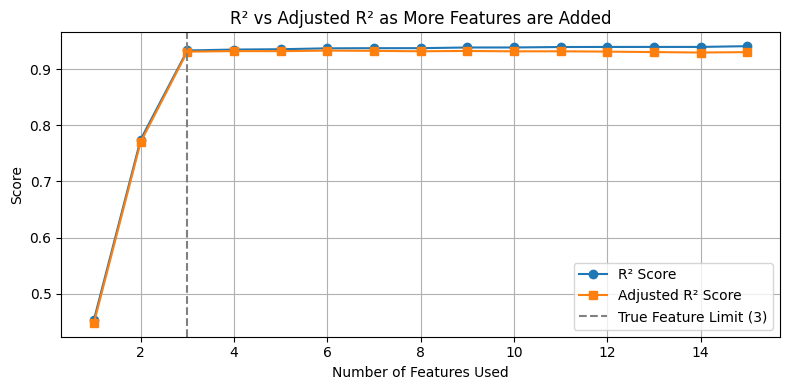

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Adjusted R² formula
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Generate synthetic data
np.random.seed(42)
n_samples = 100
n_total_features = 15

# Only first 3 features are useful
X = np.random.randn(n_samples, n_total_features)  # random feature matrix X 
                                                  # of shape (n_samples, n_total_features)
true_weights = np.array([3, -2, 1.5] + [0] * (n_total_features - 3))  # only 3 useful
y = X @ true_weights + np.random.randn(n_samples)  # noise added

# Store R² and adjusted R² as we add more features
r2_scores = []
adj_r2_scores = []
num_features_list = list(range(1, n_total_features + 1))

for p in num_features_list:
    X_subset = X[:, :p]                               # get few features
    model = LinearRegression().fit(X_subset, y)       # fit linear regression model
    y_pred = model.predict(X_subset)                  # predict on fitted data

    # compute r2 and adjusted r2
    r2 = r2_score(y, y_pred)
    adj_r2 = adjusted_r2(r2, n=n_samples, p=p)

    # store computed values
    r2_scores.append(r2)
    adj_r2_scores.append(adj_r2)

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(num_features_list, r2_scores, label='R² Score', marker='o')
plt.plot(num_features_list, adj_r2_scores, label='Adjusted R² Score', marker='s')
plt.axvline(3, color='gray', linestyle='--', label='True Feature Limit (3)')
plt.xlabel('Number of Features Used')
plt.ylabel('Score')
plt.title('R² vs Adjusted R² as More Features are Added')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Assumptions of Linear Regression ?

> - **Linearity**
>   - relationship b/w target and feature is linear
>   - can be checked with a scatter plot
> - **Independence of errors**
>   - residuals should be independent of each other
>   - durbin-watson test
> - **Homoscedasticity**
>   - variance of residuals should be constant across all levels of X
>   - residuals vs. predicted plot
> - **Normality of error**
>   - residuals should be normally distributed
>   - q-q plot, histogram of residuals
> - **No Multicollinearity**
>   - independent variables should not be highly correlated with each other
>   - Correlation matrix  

In [56]:
import seaborn as sns
import scipy.stats as stats
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Generate synthetic regression data
np.random.seed(42)
X, y = make_regression(n_samples=200, n_features=3, noise=20, coef=False)

# Convert to DataFrame
X = pd.DataFrame(X, columns=['X1', 'X2', 'X3'])
y = pd.Series(y, name='target')

# Fit linear regression using sklearn
model = LinearRegression()
model.fit(X, y)

# Predictions and residuals
y_pred = model.predict(X)
residuals = y - y_pred

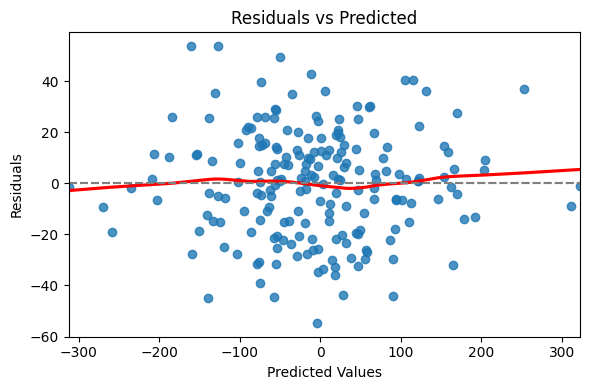

In [57]:
# Assumption: Linearity + Homoscedasticity
plt.figure(figsize=(6, 4))
sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={"color": "red"})
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.axhline(0, linestyle="--", color="gray")
plt.tight_layout()
plt.show()

> - blue dots tells how far the prediction was from actual for given predicted value. The plot shows randomness of residuals.
> - red line is locally weighted regression line (usually using LOWESS)
>   - shows the average trend in residuals across predicted values
>   - it should be flat and near 0 which indicates no pattern and that linearity is okay.

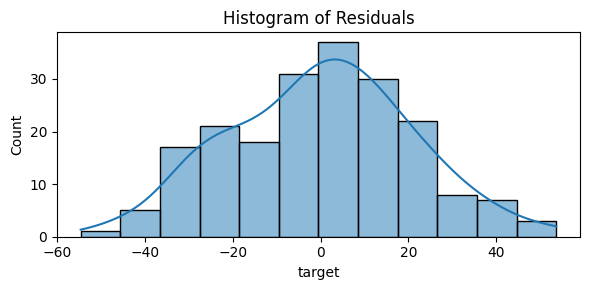

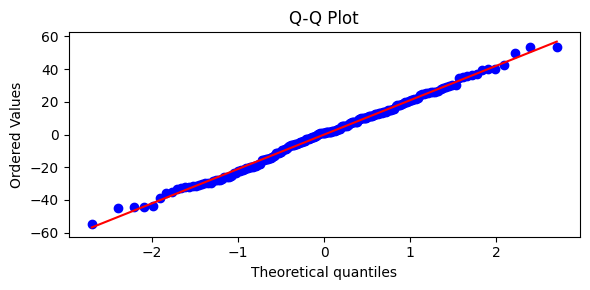

In [58]:
# Assumption: Normality of residuals
plt.figure(figsize=(6, 3))
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.tight_layout()
plt.show()

# Q-Q plot
plt.figure(figsize=(6, 3))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.tight_layout()
plt.show()

In [59]:
# Assumption: Independence - Durbin-Watson
dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw_stat:.3f} (1.5 < DW < 2.5 is usually OK)")

Durbin-Watson statistic: 1.912 (1.5 < DW < 2.5 is usually OK)


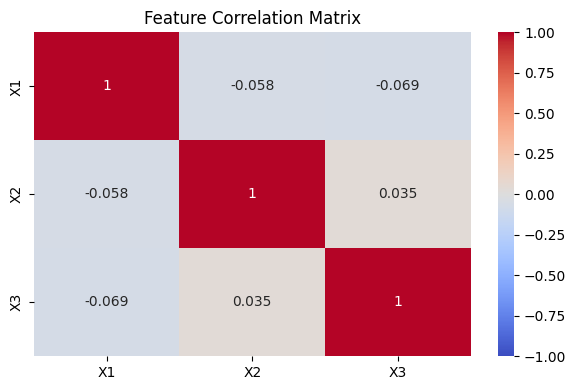

In [60]:
# Assumption: Multicollinearity - Correlation Matrix
corr_matrix = X.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# What is Central Limit Theorem ?

> If you take many random samples from any population (regardless of its shape), the distribution of the sample means will approximate a normal distribution as the sample size increases.

> In simple words,
> - Even if your data is not normally distributed, the mean of repeated random samples from it will be:
>   - approximately normal
>   - centered at the population mean (μ)
>   - with a standard deviation of σ / √n (called Standard Error) 

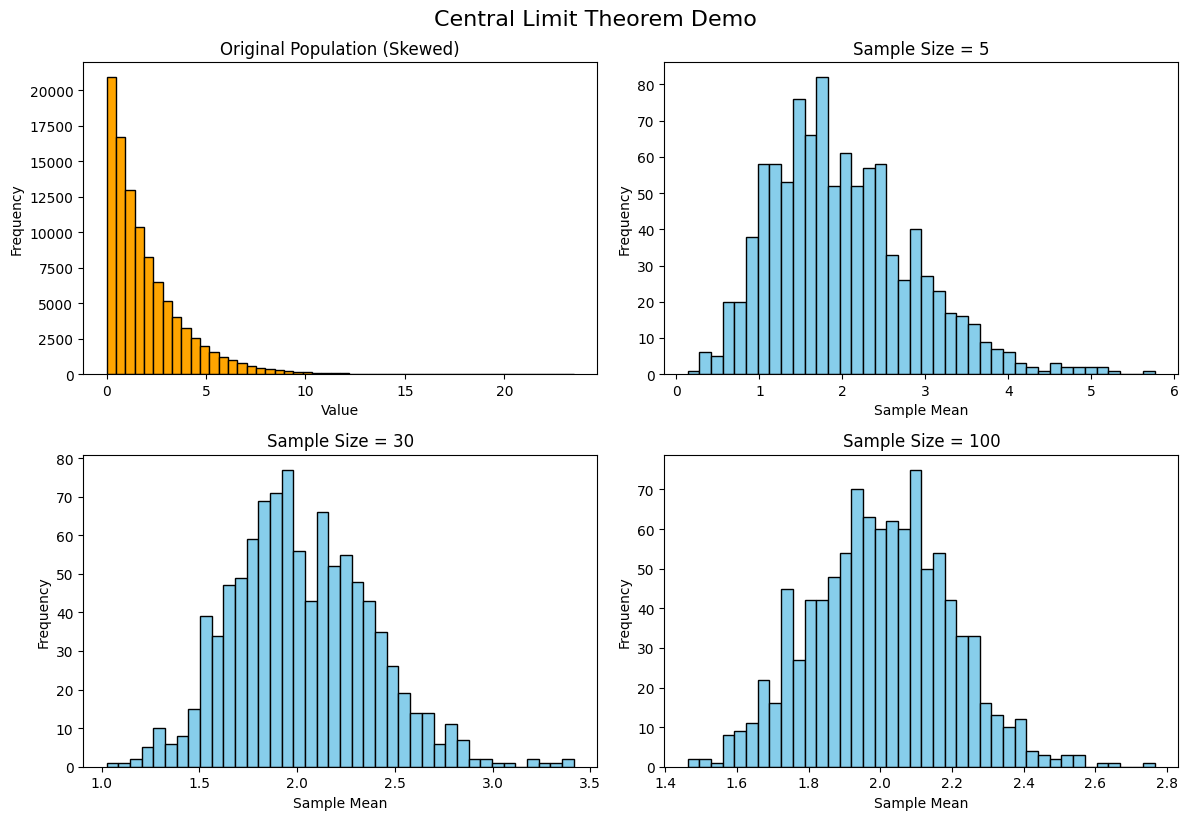

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Original skewed population
np.random.seed(42)
population = np.random.exponential(scale=2.0, size=100000)

# Sample sizes to test
sample_sizes = [5, 30, 100]
n_samples = 1000  # Number of samples to draw per sample size

# Create subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Original population
axes[0, 0].hist(population, bins=50, color='orange', edgecolor='black')
axes[0, 0].set_title("Original Population (Skewed)")
axes[0, 0].set_xlabel("Value")
axes[0, 0].set_ylabel("Frequency")

# Plot 2–4: Sampling distribution for different sample sizes
for idx, n in enumerate(sample_sizes):
    sample_means = []
    for _ in range(n_samples):
        sample = np.random.choice(population, size=n)
        sample_means.append(np.mean(sample))
    
    row = (idx + 1) // 2  # 0 or 1
    col = (idx + 1) % 2   # 1 or 0 (because we skip axes[0,1])

    axes[row, col].hist(sample_means, bins=40, color='skyblue', edgecolor='black')
    axes[row, col].set_title(f"Sample Size = {n}")
    axes[row, col].set_xlabel("Sample Mean")
    axes[row, col].set_ylabel("Frequency")

plt.tight_layout()
plt.suptitle("Central Limit Theorem Demo", fontsize=16, y=1.02)
plt.show()

# What is Bias-Variance trade off ?

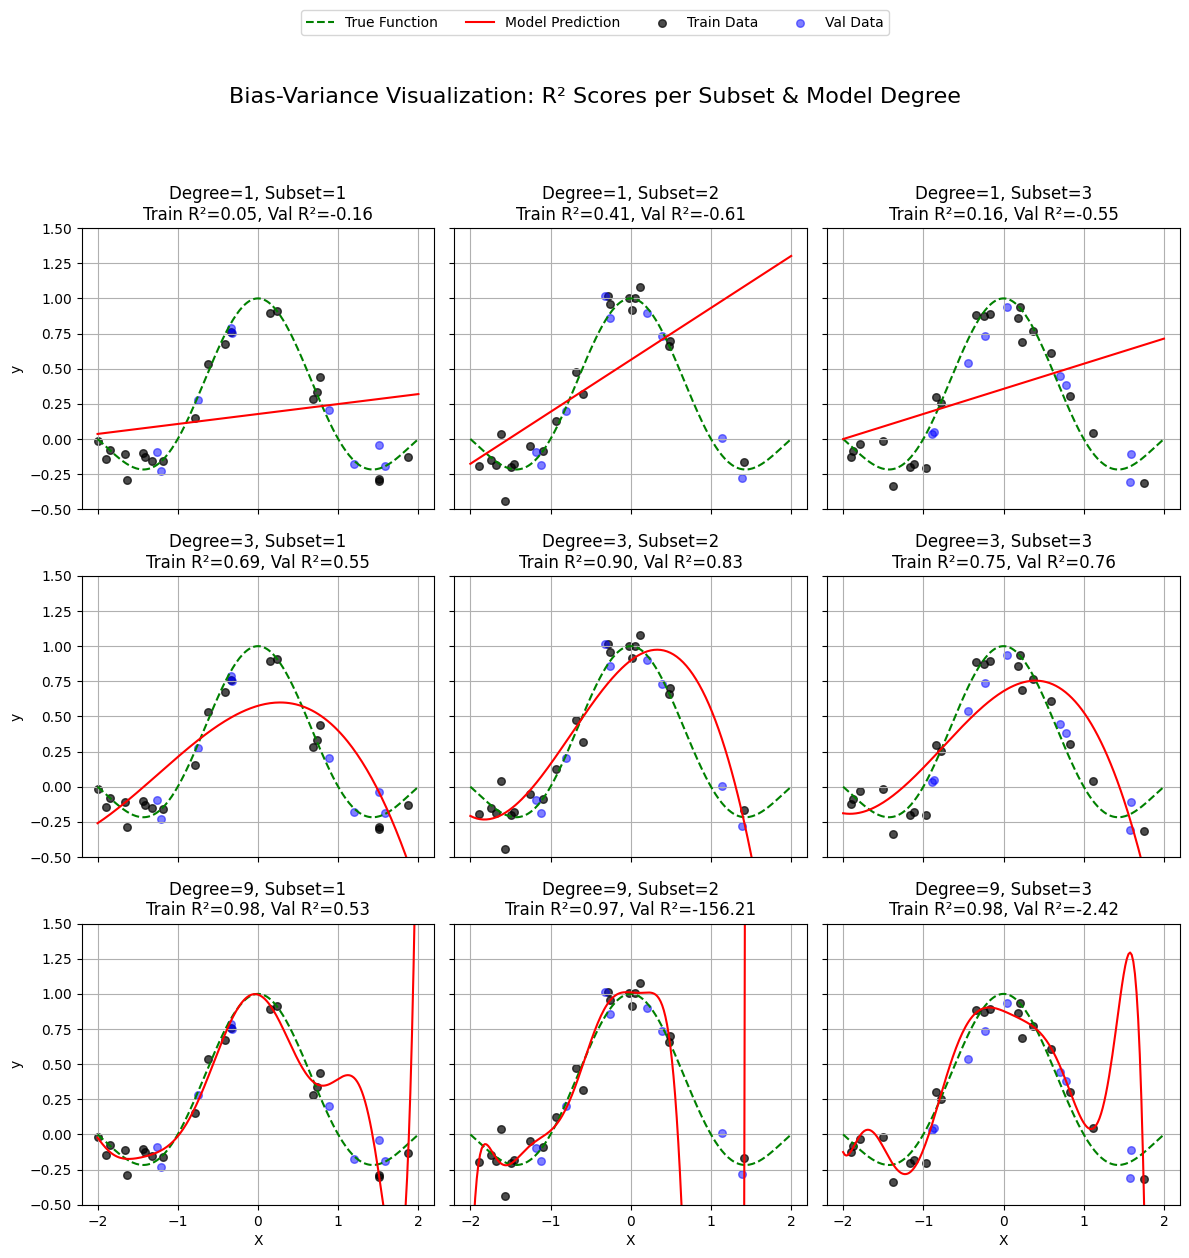

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Function to generate data
def generate_data(seed, n_samples=30):
    np.random.seed(seed)
    X = np.sort(np.random.rand(n_samples, 1) * 4 - 2, axis=0)  # random in [-2,2)
    y = np.sinc(X).ravel() + 0.1 * np.random.randn(n_samples)  # mimics sinc(x)
    return X, y

# Define test set and true function
X_test = np.linspace(-2, 2, 200).reshape(-1, 1)
y_true = np.sinc(X_test).ravel()

# Model complexities (degrees) and data subsets (seeds)
degrees = [1, 3, 9]
seeds = [1, 2, 3]

# Create 3x3 grid of plots
fig, axes = plt.subplots(3, 3, figsize=(12, 12), 
                         sharex=True, sharey=True)

for i, degree in enumerate(degrees):
    for j, seed in enumerate(seeds):
        # Generate training data
        X, y = generate_data(seed)
        X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                          test_size=0.3, random_state=42)
        
        # Create and train model
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        model.fit(X_train, y_train)

        # Predict
        y_pred_test = model.predict(X_test)
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)

        # R² scores
        r2_train = r2_score(y_train, y_pred_train)
        r2_val = r2_score(y_val, y_pred_val)

        # Plot
        ax = axes[i, j]
        ax.plot(X_test, y_true, 'g--', label='True Function')   # true values of sinc(x)
        ax.plot(X_test, y_pred_test, 'r', label='Model Prediction')  # predicted
        # plotting the train set
        ax.scatter(X_train, y_train, color='black', label='Train Data', s=30, alpha=0.7)
        
        # plotting the validation set
        ax.scatter(X_val, y_val, color='blue', label='Val Data', s=30, alpha=0.5)
        ax.set_title(f'Degree={degree}, Subset={j+1}\nTrain R²={r2_train:.2f}, Val R²={r2_val:.2f}')
        ax.grid(True)
        if i == 2:
            ax.set_xlabel('X')
        if j == 0:
            ax.set_ylabel('y')
        ax.set_ylim(-0.5, 1.5)

# Add legend and layout
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4)
plt.suptitle("Bias-Variance Visualization: R² Scores per Subset & Model Degree", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# What is SMOTE ?

> - SMOTE = Synthetic Minority Over-sampling Technique --> uses interpolation, not duplication
> - It generates synthetic (new) samples for the minority class.
> - Helps balance class distribution without simply duplicating existing points.

> - Step-by-step:
>   - For each sample x in the minority class:
>     - Find its k nearest neighbors (typically k=5) within the minority class.
>     - Randomly choose 1 (or more) neighbors, say $x_\text{neighbor}$
>     - Create synthetic sample: $$
x_{\text{new}} = x + \lambda \cdot (x_{\text{neighbor}} - x) \quad \text{where} \quad \lambda \sim \text{Uniform}(0, 1)
$$

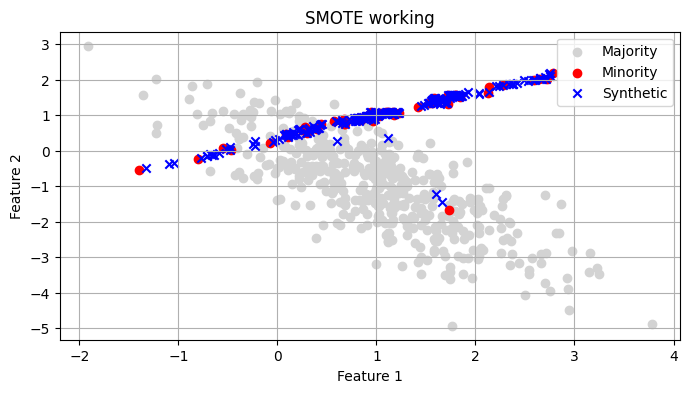

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.neighbors import NearestNeighbors

# SMOTE Function
def smote(X_minority, N=100, k=5):
    '''
    X_minority: input data from the minority class
    N: 100% more samples
    k: number of nearest neighbours to consider for interpolation
    '''
    n_samples, n_features = X_minority.shape
    n_synthetic = (N // 100) * n_samples       # synthetic samples to create

    # Find k nearest neighbors for each minority sample
    nn = NearestNeighbors(n_neighbors=k+1)     # Fit k-nn model on minority data
    nn.fit(X_minority)
    neighbors = nn.kneighbors(X_minority, return_distance=False)[:, 1:]  # exclude self

    synthetic_samples = []
    for i in range(n_synthetic):
        sample_idx = i % n_samples
        x_i = X_minority[sample_idx]                            # pick sample from X_minority
        neighbor_idx = np.random.choice(neighbors[sample_idx])  # choose a random neighbour
        x_neighbor = X_minority[neighbor_idx]

        # Interpolate between x_i and x_neighbor
        ### Compute the vector between x_i and its neighbor
        ### Generate a random point along that vector using gap ∈ [0, 1]
        diff = x_neighbor - x_i
        gap = np.random.rand()
        synthetic = x_i + gap * diff
        synthetic_samples.append(synthetic)

    return np.array(synthetic_samples)

# Generate Imbalanced Dataset
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.9, 0.1],
                           random_state=42)

X_min = X[y == 1]
X_maj = X[y == 0]

# Apply SMOTE
X_syn = smote(X_minority=X_min, N=400, k=5)

# Combine Data
X_combined = np.vstack((X, X_syn))
y_combined = np.hstack((y, np.ones(len(X_syn))))

# Step 5: Visualization
plt.figure(figsize=(8, 4))
plt.scatter(X_maj[:, 0], X_maj[:, 1], color='lightgray', label='Majority')
plt.scatter(X_min[:, 0], X_min[:, 1], color='red', label='Minority')
plt.scatter(X_syn[:, 0], X_syn[:, 1], color='blue', marker='x', label='Synthetic')
plt.title("SMOTE working")
plt.legend()
plt.grid(True)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# What is effect of batch size on overfitting ?

> - Batch size is the number of training samples used to compute the gradient and update the weights once during training.
> - Small batch size leads to more noisy updates, which helps escape local minima --> less overfitting.
> - Large batch size leads to faster convergence, but may get stuck in local minima --> more prone to overfitting.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


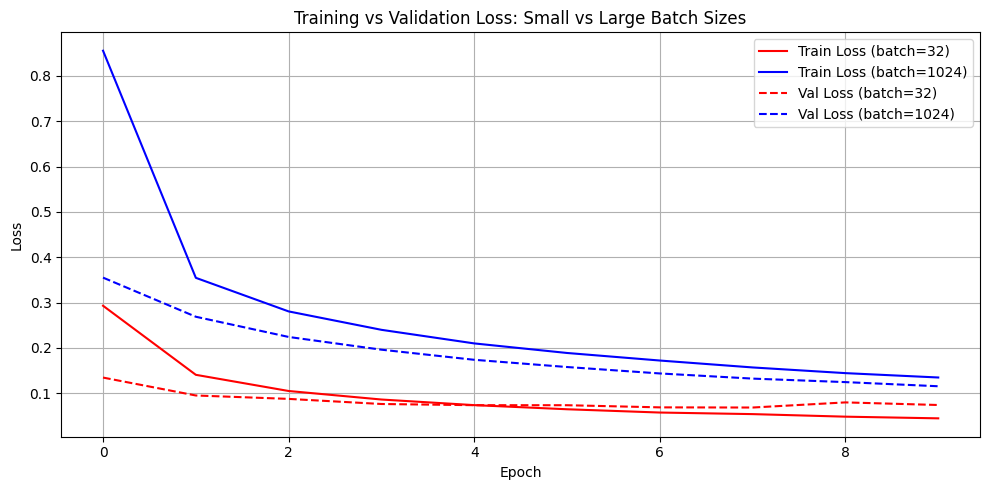

In [66]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST
(x_train, y_train), (x_val, y_val) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28*28) / 255.0
x_val = x_val.reshape(-1, 28*28) / 255.0

# Build a simple model
def create_model():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Train with small batch size
model_small = create_model()
history_small = model_small.fit(
    x_train, y_train, 
    epochs=10, 
    batch_size=32, 
    validation_data=(x_val, y_val),
    verbose=0
)

# Train with large batch size
model_large = create_model()
history_large = model_large.fit(
    x_train, y_train, 
    epochs=10, 
    batch_size=1024, 
    validation_data=(x_val, y_val),
    verbose=0
)

# Plot losses
plt.figure(figsize=(10, 5))

# Plot training loss
plt.plot(history_small.history['loss'], 'r-', label='Train Loss (batch=32)')
plt.plot(history_large.history['loss'], 'b-', label='Train Loss (batch=1024)')

# Plot validation loss
plt.plot(history_small.history['val_loss'], 'r--', label='Val Loss (batch=32)')
plt.plot(history_large.history['val_loss'], 'b--', label='Val Loss (batch=1024)')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss: Small vs Large Batch Sizes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**key takeaways**
> - smaller batch size decreases gradually, but ends lower.
> - larger batch size decreases quickly, but settles higher.

# How does Gradient Boosting works ?

**Key Steps :**
> - Initialize the model
>   - Start with constant prediction. This is usually mean of the target variable.
> - For **each iteration**,
>   - Compute residuals. This tells how much far is current model's predictions.
>   - Fit a **weak learner** --> typically a small decision tree.
>     - **Train on X and residuals**
> - Update the model
> - Final Prediction      

Building tree 1 ...
	residual sum (pre-training): 0.0
	residual sum (post-training): -6.827871601444713e-15
Building tree 2 ...
	residual sum (pre-training): -1.2212453270876722e-15
	residual sum (post-training): -4.773959005888173e-15
Building tree 3 ...
	residual sum (pre-training): 1.5543122344752192e-15
	residual sum (post-training): 8.215650382226158e-15
Building tree 4 ...
	residual sum (pre-training): -2.3314683517128287e-15
	residual sum (post-training): -4.218847493575595e-15
Building tree 5 ...
	residual sum (pre-training): 6.661338147750939e-16
	residual sum (post-training): 1.762479051592436e-15
Building tree 6 ...
	residual sum (pre-training): 1.4432899320127035e-15
	residual sum (post-training): -2.220446049250313e-16
Building tree 7 ...
	residual sum (pre-training): 2.886579864025407e-15
	residual sum (post-training): -3.3480163086352377e-16
Building tree 8 ...
	residual sum (pre-training): 3.1086244689504383e-15
	residual sum (post-training): 4.218847493575595e-15
Build

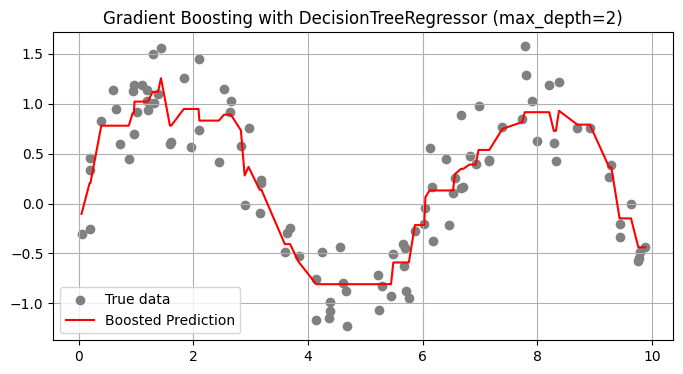

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Generate synthetic regression data
np.random.seed(0)
X = np.sort(np.random.rand(100, 1) * 10, axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.3, size=X.shape[0])

# Gradient Boosting Regressor using sklearn trees
class GradientBoostingScratch:
    def __init__(self, n_estimators=10, learning_rate=0.1, max_depth=1):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.models = []

    def fit(self, X, y):
        self.init_pred = np.mean(y)
        y_pred = np.full_like(y, self.init_pred)
        
        for i in range(self.n_estimators):  # repeat for each estimator (weak learner)
            print("Building tree {} ...".format(i+1))
            
            residual = y - y_pred           # Gradient for MSE
            print("\tresidual sum (pre-training): {}".format(residual.sum()))
            
            tree = DecisionTreeRegressor(max_depth=self.max_depth)   # weak learner
            tree.fit(X, residual)                               # fitting on X and residuals

            residual_predict = tree.predict(X)        # with this tree, we will predict X
            print("\tresidual sum (post-training): {}".format(residual_predict.sum()))
            
            y_pred += self.learning_rate * residual_predict
            self.models.append(tree)

    def predict(self, X):
        y_pred = np.full(X.shape[0], self.init_pred)
        for tree in self.models:
            y_pred += self.learning_rate * tree.predict(X)
        return y_pred

# Step 3: Train the boosting model
gbr = GradientBoostingScratch(n_estimators=20, learning_rate=0.3, max_depth=2)
gbr.fit(X, y)
y_pred = gbr.predict(X)

# Step 4: Plot
plt.figure(figsize=(8, 4))
plt.scatter(X, y, label="True data", color='gray')
plt.plot(X, y_pred, label="Boosted Prediction", color='red')
plt.title("Gradient Boosting with DecisionTreeRegressor (max_depth=2)")
plt.legend()
plt.grid(True)
plt.show()

In [68]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluate model performance
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("\nModel Performance:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")


Model Performance:
Mean Squared Error (MSE): 0.0572
Root Mean Squared Error (RMSE): 0.2391
Mean Absolute Error (MAE): 0.1902
R² Score: 0.8966


# DBSCAN Clustering (Density-Based Spatial Clustering of Applications with Noise)

- All points are labelled as "UNVISITED".
- For each point P in dataset,
  - If P is already visited, skip to the next point.
  - Mark P as VISITED.
  - Retrieve P’s ε-neighborhood: all points within ε (epsilon) distance.
- Check density condition:
  - If the number of neighbors < minPts:
    - Label P as **non-core point**.
  - Else:
    - Label P as **core point**
- Starting with a random core point, keep extending neighbouring core points to this cluster.
- A Non-core point near to a core point can be added to this cluster. **But, a non-core point can not be used to extend the cluster**.
- Expand the cluster

In [69]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300,
                  centers=3,
                  cluster_std=0.1,
                  random_state=42)

In [70]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X)

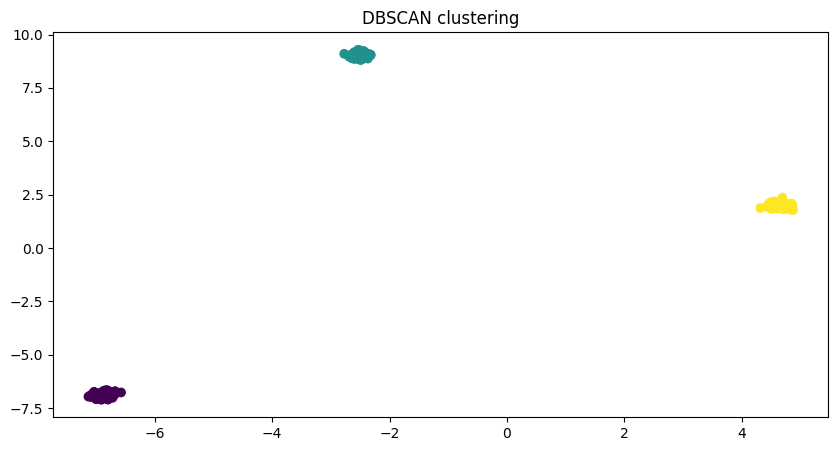

In [71]:
plt.figure(figsize=(10,5))
plt.scatter(X[:,0], X[:, 1], c=labels)
plt.title("DBSCAN clustering")
plt.show()

# What is Hierarchical Clustering?

Hierarchical clustering groups similar data points by creating a hierarchy of clusters. It’s visualized using a dendrogram, a tree diagram that shows how clusters are merged or split at each step.

It has two main approaches -
- Agglomerative --> BOTTOM UP
  - Starts with each data point as its own cluster.
  - Iteratively merge the closest clusters based on some distance criteria, like Eucledian Distance.
  - Continue until all points are in one cluster or a stopping criteria is met.
- Divisive --> TOP DOWN
  - Start with all data points in one cluster.
  - Recursively split the cluster into smaller ones.
  - Continue until each point is its own cluster or a desired number of clusters is reached.

In [72]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300,
                  centers=3,
                  cluster_std=0.3,
                  random_state=42)

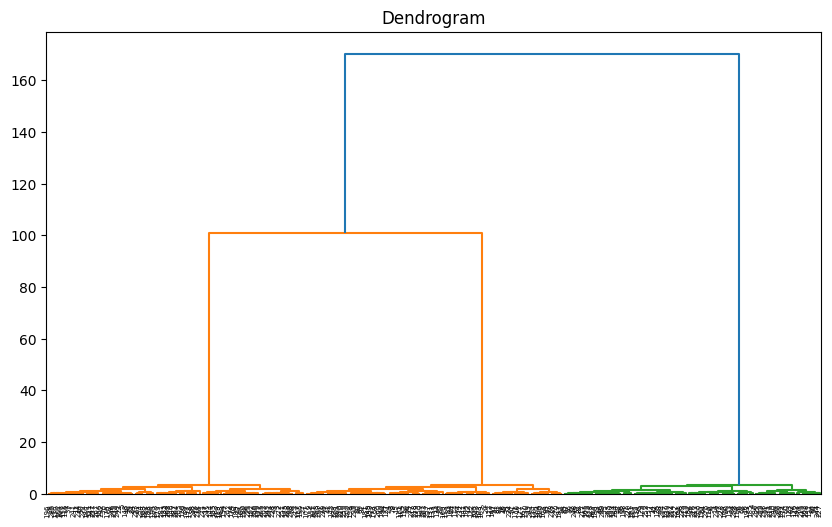

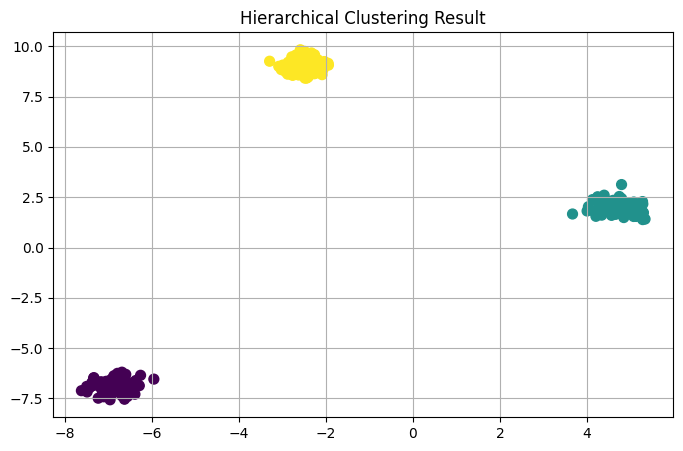

In [73]:
from scipy.cluster.hierarchy import linkage,dendrogram
from sklearn.cluster import AgglomerativeClustering

linked = linkage(X, method='ward')   # 'ward' minimizes variance within clusters

plt.figure(figsize=(10,6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)
plt.title("Dendrogram")
plt.show()

cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
labels = cluster.fit_predict(X)

# Step 6: Visualize clustered data
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title("Hierarchical Clustering Result")
plt.grid(True)
plt.show()
